# Demo Exploration


In [2]:
import cv2
import numpy as np
import time
import torch
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
import os
from densenet import DenseNet2D
from mobilenet_v1 import MobileNet2D_V1
from utils import GeneralizedDiceLoss
import utils
from PIL import Image

(400, 640)
Image dimensions: 256x256 pixels


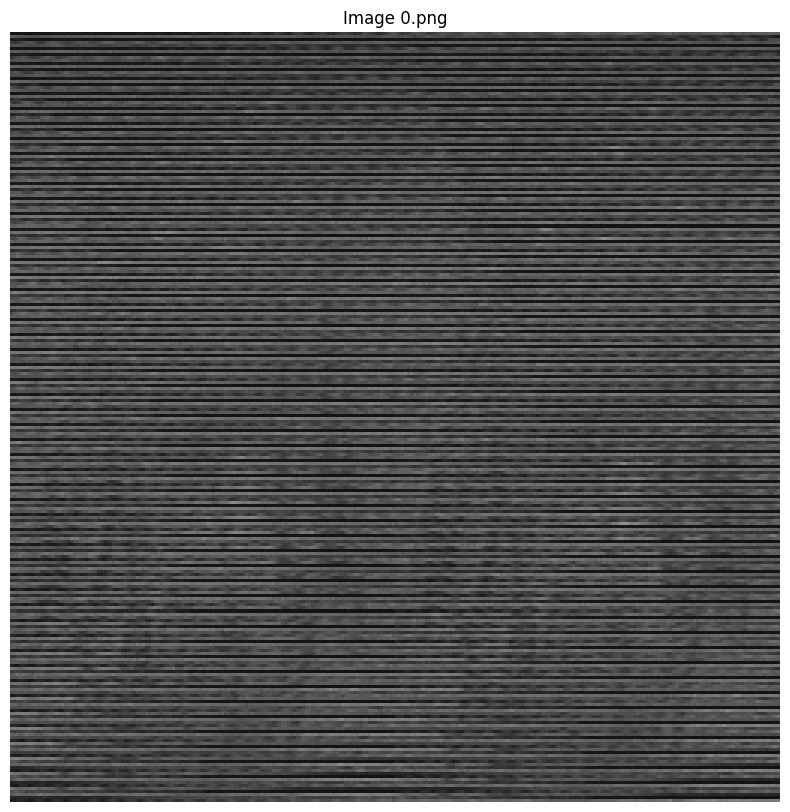

: 

In [ ]:


# Load the image
img = cv2.imread(r'C:\Users\hayde\OneDrive\Documents\Y5S2\Medical_Image_Processing\demo\1.png')
gray_frame = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imshow('gray_frame', gray_frame)
print(gray_frame.shape)
img = np.resize(gray_frame, (256,256))
# Check if image was loaded successfully
if img is None:
    print('Error: Could not load image 1.png')
else:
    # Get image dimensions
    height, width = img.shape[:2]
    print(f'Image dimensions: {width}x{height} pixels')
    
    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
    plt.title('Image 0.png')
    plt.axis('off')
    plt.show()


In [16]:
try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    

    model = MobileNet2D_V1(dropout=False)
    model = model.to(device)
    # Load the state dictionary
    model_path = r"C:\Users\hayde\OneDrive\Documents\Y5S2\Medical_Image_Processing\demo\TRAIN_MOBILE_V1.pkl"
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at {model_path}")

    keyMatch = model.load_state_dict(torch.load(model_path))
    print(keyMatch)
    model = model.to(device)
    model.eval()
    print("Model loaded successfully")
    
except Exception as e:
    print(f"Error loading model: {e}")


Using device: cuda
<All keys matched successfully>
Model loaded successfully


(400, 640)
torch.Size([1, 4, 400, 640])
torch.Size([1, 400, 640])
(1, 400, 640)


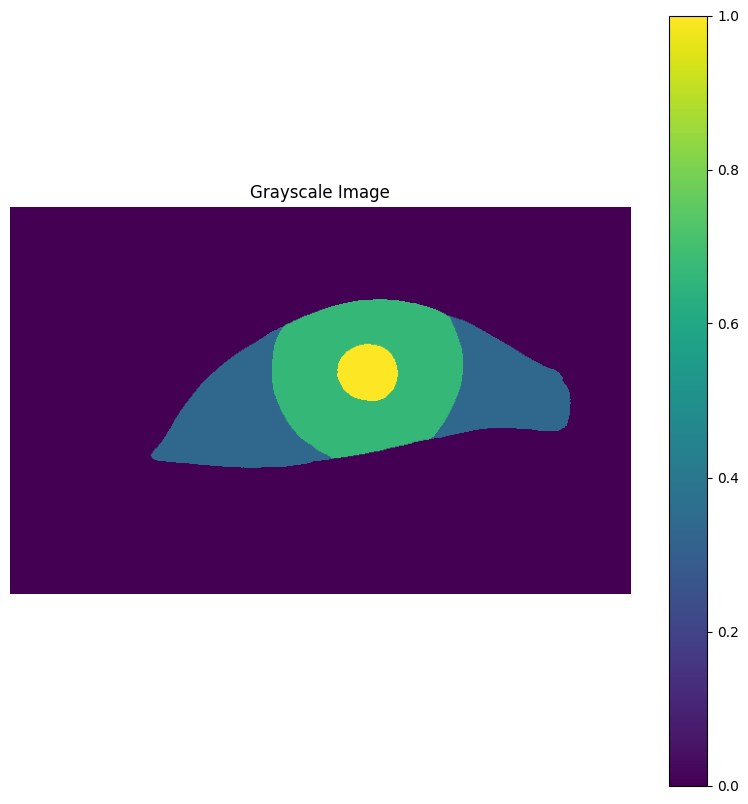

<Figure size 640x480 with 0 Axes>

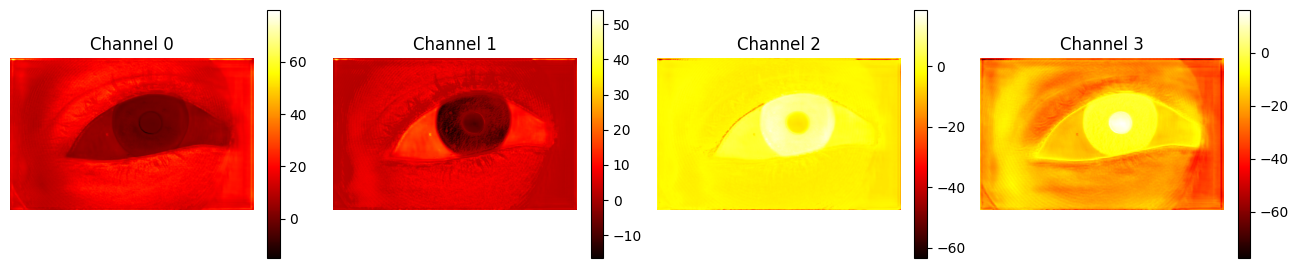

In [19]:
# Define the transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

gray_frame = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
pil_image = Image.fromarray(gray_frame)
print(gray_frame.shape)
img_tensor = transform(pil_image)
img_tensor = img_tensor.unsqueeze(0)

img_tensor = img_tensor.to(device)


output = model(img_tensor)
print(output.shape)


pred_map = utils.get_predictions(output)
print(pred_map.shape)
pred_img = pred_map.cpu().numpy()/3.0
print(pred_img.shape)
pred_img= pred_img.squeeze(0)

plt.figure(figsize=(10, 10))
plt.imshow(pred_img)
plt.colorbar()
plt.title('Grayscale Image')
plt.axis('off')
plt.show()


plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    output_plot = output.detach().cpu().numpy()[:,i,:,:]
    output_plot=output_plot.squeeze(0)
    im = axes[i].imshow(output_plot, cmap='hot')
    axes[i].set_title(f'Channel {i}')
    axes[i].axis('off')
    
    # Add colorbar to each subplot
    plt.colorbar(im, ax=axes[i], fraction=0.046)
